In [46]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/jihyeseo/seoulairreport/SeoulHourlyAvgAirPollution.csv


In [47]:
df = pd.read_csv('/kaggle/input/datasets/jihyeseo/seoulairreport/SeoulHourlyAvgAirPollution.csv')

In [48]:
print(df.describe())

               측정일시  이산화질소농도(ppm)    오존농도(ppm)  일산화탄소농도(ppm)   아황산가스(ppm)  \
count  4.225000e+03   4187.000000  4183.000000   4183.000000  4187.000000   
mean   2.017112e+11      0.028922     0.013460      0.561009     0.004693   
std    2.017632e+04      0.015733     0.009577      0.236955     0.001304   
min    2.017112e+11      0.005000     0.001000      0.100000     0.002000   
25%    2.017112e+11      0.015000     0.004000      0.400000     0.004000   
50%    2.017112e+11      0.026000     0.012000      0.500000     0.005000   
75%    2.017112e+11      0.041000     0.021000      0.700000     0.006000   
max    2.017112e+11      0.092000     0.042000      1.800000     0.010000   

         미세먼지(㎍/㎥)   초미세먼지(㎍/㎥)  
count  4166.000000  4161.000000  
mean     36.724436    19.882480  
std      22.585665    12.798846  
min       5.000000     3.000000  
25%      22.000000    10.000000  
50%      30.000000    15.000000  
75%      46.000000    27.000000  
max     228.000000    85.000000  


In [49]:
import pandas as pd
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler

df.rename(columns={'측정일시':'Date/Time','측정소명':'Location','이산화질소농도(ppm)':'NO2', '오존농도(ppm)':'O3','일산화탄소농도(ppm)':'CO','아황산가스(ppm)':'SO2','미세먼지(㎍/㎥)':'Fine Dust','초미세먼지(㎍/㎥)':'Ultrafine Dust'}, inplace=True)
df.head()

num_cols = df.columns[2:]                     # NO2 ~ Ultrafine Dust

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# 2. 이상치: 4개 가스 중 하나라도 |Z| > 3인 행 제거
z_cols = ['NO2', 'O3', 'CO', 'SO2']
z = df[z_cols].apply(zscore)
altered = df[(z.abs() <= 3).all(axis=1)].copy()

# 3. 스케일링: 0~1 범위의 _scaled 열 추가
scaled_cols = [f'{c}_scaled' for c in num_cols]
altered[scaled_cols] = MinMaxScaler().fit_transform(altered[num_cols])

# 4. 인코딩: Location 원-핫 후 원본 문자열 열 제거
df = pd.get_dummies(df, columns=['Location'])
df.head()

# 확인
print(encoded_df.shape)
print('결측치:', encoded_df.isnull().sum().sum())           # 0이어야 정상
print(encoded_df[scaled_cols].agg(['min', 'max']))          # 0과 1이어야 정상
df.head()


(4162, 38)
결측치: 0
     NO2_scaled  O3_scaled  CO_scaled  SO2_scaled  Fine Dust_scaled  \
min         0.0        0.0        0.0         0.0               0.0   
max         1.0        1.0        1.0         1.0               1.0   

     Ultrafine Dust_scaled  
min                    0.0  
max                    1.0  


,Date/Time,NO2,O3,CO,SO2,Fine Dust,Ultrafine Dust,Location_강남구,Location_강동구,Location_강북구,...,Location_성동구,Location_성북구,Location_송파구,Location_양천구,Location_영등포구,Location_용산구,Location_은평구,Location_종로구,Location_중구,Location_중랑구
0,201711242300,0.038,0.004,0.4,0.005,16.0,10.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,201711242200,0.031,0.008,0.4,0.005,17.0,9.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,201711242100,0.025,0.012,0.4,0.005,18.0,11.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,201711242000,0.033,0.007,0.4,0.005,21.0,12.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,201711241900,0.033,0.008,0.4,0.005,20.0,10.0,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [50]:
df['Target'] = df['Fine Dust']
df.drop(['Fine Dust'],axis=1,inplace=True)
df.head()

,Date/Time,NO2,O3,CO,SO2,Ultrafine Dust,Location_강남구,Location_강동구,Location_강북구,Location_강서구,...,Location_성북구,Location_송파구,Location_양천구,Location_영등포구,Location_용산구,Location_은평구,Location_종로구,Location_중구,Location_중랑구,Target
0,201711242300,0.038,0.004,0.4,0.005,10.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,16.0
1,201711242200,0.031,0.008,0.4,0.005,9.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,17.0
2,201711242100,0.025,0.012,0.4,0.005,11.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,18.0
3,201711242000,0.033,0.007,0.4,0.005,12.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,21.0
4,201711241900,0.033,0.008,0.4,0.005,10.0,True,False,False,False,...,False,False,False,False,False,False,False,False,False,20.0


In [51]:
from sklearn.model_selection import train_test_split

X = df.drop(columns='Target')
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3380, 31) (845, 31) (3380,) (845,)


In [52]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

regr = LinearRegression()

regr.fit(X_train, y_train)

y_pred = regr.predict(X_test)

print("Mean squared error: %.8f" % mean_squared_error(y_test, y_pred))
      
print('Variance R2 score: %.8f' % r2_score(y_test, y_pred))

Mean squared error: 176.71503325
Variance R2 score: 0.63876690


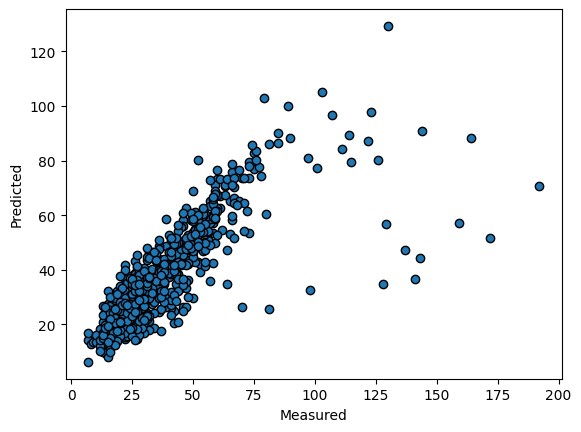

In [58]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.scatter(y_test, y_pred, edgecolors=(0, 0, 0))

ax.set_xlabel('Measured')
ax.set_ylabel('Predicted')


plt.show()

In [61]:
sub = pd.read_csv('/kaggle/input/대회명/sample_submission.csv')
sub['Target'] = regr.predict(X_test)
sub.to_csv('submission.csv', index=False)

NameError: name 'sub' is not defined